In [1]:
!hostname

gpua026.delta.ncsa.illinois.edu


In [2]:
# Load OT translation result from the portable export (env-agnostic).
# Falls back to the original cloudpickle if the portable dir is missing.
# Downstream cells only need: `transports`, `obs_src_per_pair`, `obs_tgt_per_pair`.
import json, numpy as np, pandas as pd
from pathlib import Path

PORTABLE_DIR = Path("/projects/bhdw/asachan/tmp/tp_atac_rna_skm_portable")
PICKLE_PATH  = Path("/projects/bhdw/asachan/tmp/tp_atac_rna_skm.pkl")

if (PORTABLE_DIR / "manifest.json").exists():
    manifest = json.loads((PORTABLE_DIR / "manifest.json").read_text())
    transports, obs_src_per_pair, obs_tgt_per_pair = {}, {}, {}
    for p in manifest["problems"]:
        key = (p["src_sample"], p["tgt_sample"])
        transports[key]       = np.load(PORTABLE_DIR / p["T_file"])["T"]
        obs_src_per_pair[key] = pd.read_parquet(PORTABLE_DIR / p["obs_src_file"])
        obs_tgt_per_pair[key] = pd.read_parquet(PORTABLE_DIR / p["obs_tgt_file"])
    tp = None
    print(f"loaded portable export: {len(transports)} transport matrices "
          f"from {PORTABLE_DIR}")
else:
    import pickle
    with open(PICKLE_PATH, "rb") as f:
        tp = pickle.load(f)
    transports       = {k: np.asarray(p.solution.transport_matrix) for k, p in tp.problems.items()}
    obs_src_per_pair = {k: p.adata_src.obs for k, p in tp.problems.items()}
    obs_tgt_per_pair = {k: p.adata_tgt.obs for k, p in tp.problems.items()}
    print(f"loaded cloudpickle: {type(tp).__name__} ({len(transports)} subproblems)")


loaded portable export: 3 transport matrices from /projects/bhdw/asachan/tmp/tp_atac_rna_skm_portable


In [3]:
import sys
print(sys.executable)

/projects/bhdw/asachan/.conda/envs/otload/bin/python


In [4]:
import scanpy as sc
import scipy.sparse as sp
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os
os.chdir('/projects/bgdb/asachan/methods/FIREFate/moscot')  # directory containing utils.py
import sys
import logging
import warnings

export_dir = "/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human"
human_genome_path = '/work/hdd/bgdb/asachan/datasets_proj/human_genome_files'

out_tmp = '/projects/bhdw/asachan/tmp'

In [6]:
pd.set_option('mode.string_storage', 'python')

### Load learnt coupling matrix between atac and rna and joint embeddings

In [8]:
joint = ad.read_h5ad('/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/joint_atac_rna_female_type2.h5ad')

In [9]:
joint

AnnData object with n_obs × n_vars = 9819 × 50
    obs: 'orig.ident', 'sample', 'age', 'Sex', 'Annotation', 'modality', 'dataset'
    uns: 'modality_colors', 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [24]:
joint.obs['modality'].value_counts()

modality
atac    5830
rna     3989
Name: count, dtype: int64

In [23]:
joint.obs['sample'].value_counts()

sample
YM2    5338
OM9    3516
OM6     965
Name: count, dtype: int64

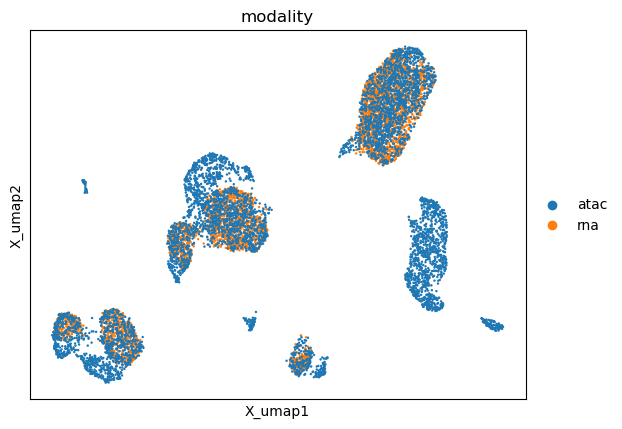

In [16]:
sc.pl.embedding(joint, basis='X_umap', color=['modality'])

In [17]:
adata_atac = sc.read_h5ad('/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/atac_objects/atac_fiber/atac_female_type2.h5ad')

In [18]:
# add age as categorical
adata_atac.obs["age_categorical"] = adata_atac.obs["age"].astype("category")

In [20]:
adata_atac

AnnData object with n_obs × n_vars = 5830 × 27649
    obs: 'replicates', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'orig.ident', 'sample', 'group', 'ReadsInPeaks', 'FRIP', 'fiber_class_1_anno', 'Annotation', 'UMAP_1', 'UMAP_2', 'fiber_class_anno', 'country', 'age', 'Sex', 'age_categorical'
    var: 'n_cells'
    uns: 'Annotation_colors', 'lsi', 'neighbors', 'sample_colors', 'umap'
    obsm: 'X_UMAP', 'X_lsi', 'X_umap'
    varm: 'LSI'
    layers: 'Tn5_insertion_counts'
    obsp: 'connectivities', 'distances'

In [22]:
adata_atac.obs['sample'].value_counts()

sample
YM2    3349
OM9    2238
OM6     243
Name: count, dtype: int64

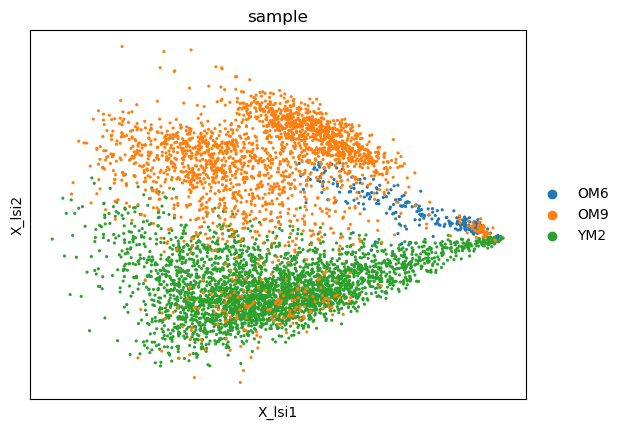

In [21]:
sc.pl.embedding(adata_atac, basis='X_lsi', color=['sample'])

In [19]:
adata_rna = sc.read_h5ad('/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad')

In [25]:
adata_rna.obs['sample'].value_counts()

sample
YM2    1989
OM9    1278
OM6     722
Name: count, dtype: int64

#### Pull soft peak accessibility onto every RNA cell — **sample-stratified** so each RNA cell receives peak mass only from same-donor ATAC. The per-sample GW solves already enforce this on the row blocks; this section assembles the global coupling correctly and adds a defensive sample-mask so cross-sample mass is exactly zero.

In [26]:
import numpy as np, scipy.sparse as sp

# Assemble the global (n_atac, n_rna) coupling by placing each per-sample
# transport block at the correct (row, col) positions on the global grid.
# obs_src_per_pair[(src,tgt)].index / obs_tgt_per_pair[(src,tgt)].index give
# the exact ATAC/RNA cell IDs at the rows/cols of each T block — works whether
# T is compact (n_src_s, n_tgt_s) or full-width.
atac_pos = {idx: i for i, idx in enumerate(adata_atac.obs.index.astype(str))}
rna_pos  = {idx: i for i, idx in enumerate(adata_rna .obs.index.astype(str))}

T_full = np.zeros((adata_atac.n_obs, adata_rna.n_obs), dtype=np.float32)
for (src_b, tgt_b), T in transports.items():
    src_obs = obs_src_per_pair[(src_b, tgt_b)].index.astype(str)
    tgt_obs = obs_tgt_per_pair[(src_b, tgt_b)].index.astype(str)
    if T.shape != (len(src_obs), len(tgt_obs)):
        raise ValueError(
            f"{src_b}->{tgt_b}: T {T.shape} != ({len(src_obs)},{len(tgt_obs)})"
        )
    src_i = np.fromiter((atac_pos[i] for i in src_obs), dtype=np.int64, count=len(src_obs))
    tgt_i = np.fromiter((rna_pos [i] for i in tgt_obs), dtype=np.int64, count=len(tgt_obs))
    T_full[np.ix_(src_i, tgt_i)] = T.astype(np.float32)
    print(f"  placed {src_b} -> {tgt_b}  block={T.shape}")

# SAMPLE-stratify (defensive) — ensures each RNA cell receives peak mass ONLY
# from ATAC cells of the *same donor*.  Per-sample GW solves already enforce
# this; this step is a no-op when the export is clean and a hard guard
# otherwise.  This is what makes a query cell's chromatin bias come from its
# own donor's ATAC even when the perturb pipeline pools across donors of the
# same age (e.g. all O80 cells from donor A and donor B).
atac_sample = adata_atac.obs["sample"].astype(str).values
rna_sample  = adata_rna .obs["sample"].astype(str).values

sample_match = atac_sample[:, None] == rna_sample[None, :]
n_xs = int(((T_full > 0) & ~sample_match).sum())
T_strat = np.where(sample_match, T_full, 0.0).astype(np.float32)
print(f"  zeroed {n_xs} cross-sample T entries (should be 0 if OT was per-sample)")

col_sum  = T_strat.sum(0, keepdims=True)
n_orphan = int((col_sum.ravel() == 0).sum())
print(f"  RNA cells with no same-sample ATAC source: {n_orphan} / {T_strat.shape[1]}")
T_col    = T_strat / np.where(col_sum > 0, col_sum, 1.0)        # column-stochastic

# soft peak matrix per RNA cell (raw Tn5 counts, not TF-IDF)
X_peak      = adata_atac.X.toarray() if sp.issparse(adata_atac.X) else adata_atac.X
X_peaks_rna = T_col.T @ X_peak                                   # (n_rna, n_peaks)

adata_rna.obsm["X_peaks_inferred"] = X_peaks_rna.astype(np.float32)
print("inferred peaks per RNA cell:", X_peaks_rna.shape,
      "  mean nnz / cell:", float((X_peaks_rna > 0).sum(1).mean()))

sample → age: {'YM2': '34', 'OM6': '80', 'OM9': '80'}
RNA cells with no age-matched ATAC source: 0 / 3989
inferred peaks per RNA cell: (3989, 27649)   mean nnz / cell: 27634.801955377287


In [27]:
import pandas as pd
# Mass each RNA cell receives, grouped by donor sample.  Within a donor we
# expect roughly uniform mean mass; orphans (mass == 0) should be 0 by
# construction since each sample has its own ATAC cells.
print(pd.DataFrame({
    "rna_sample":    rna_sample,
    "received_mass": col_sum.ravel(),
}).groupby("rna_sample")["received_mass"].agg(["mean", "std", "min", "max", "count"]))

             mean           std       min       max  count
rna_age                                                   
34       0.000251  5.620206e-09  0.000251  0.000251   1989
80       0.000502  8.283905e-07  0.000501  0.000506   2000


#### is the transition probability too diffused or does it still capture geometrical structure above uniform coupling?
#### also fewer atac-neighbours

In [28]:
import numpy as np, pandas as pd
T_col_n = T_strat / np.where(col_sum > 0, col_sum, 1.0)
H       = -(T_col_n * np.log(T_col_n + 1e-30)).sum(0)
df = pd.DataFrame({
    "sample": rna_sample,
    "top1":   T_col_n.max(0),
    "eff_k":  np.exp(H),
})
print(df.groupby("sample").agg(["median", lambda x: np.percentile(x, 95)]))

         top1                  eff_k            
       median <lambda_0>      median  <lambda_0>
age                                             
34   0.029562   0.243189  191.214188  382.317963
80   0.259530   0.499442   25.309422   97.164703


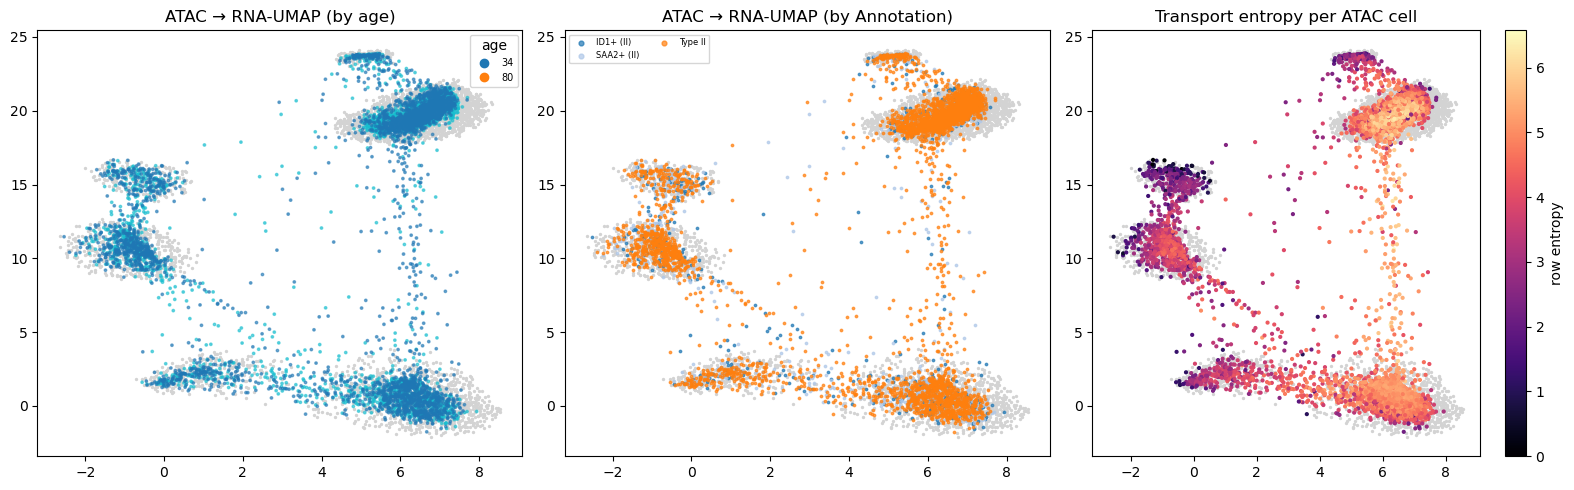

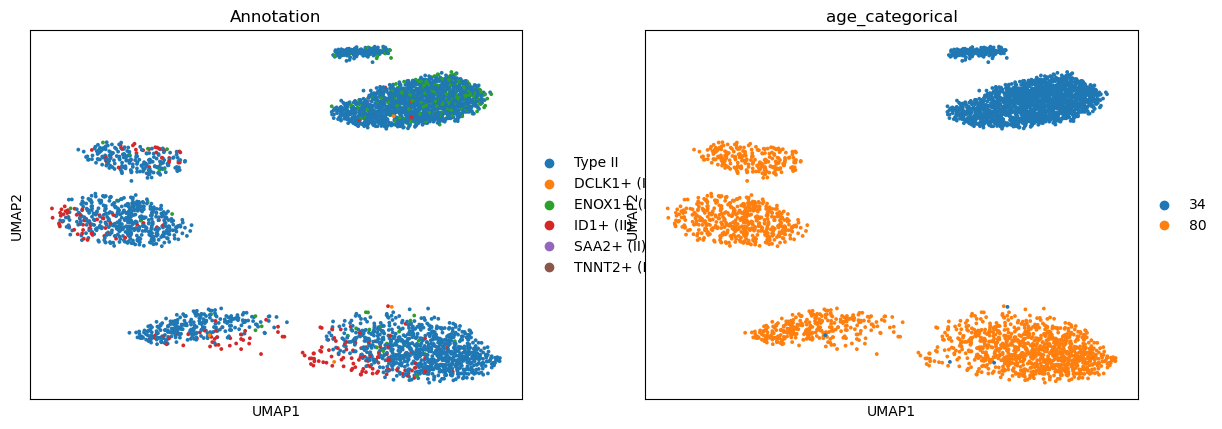

In [31]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D                                                                                                                                                     
import scanpy as sc
                                                                                                                                                                                        
# row-normalize T (one row per ATAC cell)                                                                                                                                               
row_sum = T_full.sum(1, keepdims=True)
T_row   = T_full / np.where(row_sum > 0, row_sum, 1.0)                                                                                                                                  
                                                                                                                                                                                        
U_rna           = adata_rna.obsm["X_umap"]                                                                                                                                              
U_atac_in_rna   = T_row @ U_rna                                                                                                                                                         
                                                                                                                                                                                        
fig, ax = plt.subplots(1, 3, figsize=(16, 5))                                                                                                                                           

# --- (a) projected ATAC colored by AGE                                                                                                                                                 
ages = np.unique(atac_age)
age2i = {a: i for i, a in enumerate(ages)}                                                                                                                                              
age_code = np.array([age2i[a] for a in atac_age])
cmap_age = plt.get_cmap("tab10")                                                                                                                                                        
ax[0].scatter(*U_rna.T, s=2, c="lightgrey")
ax[0].scatter(*U_atac_in_rna.T, s=3, c=age_code, cmap=cmap_age, alpha=.6)                                                                                                               
ax[0].legend(handles=[Line2D([0],[0], marker='o', linestyle='',                                                                                                                         
                            color=cmap_age(i), label=a) for a, i in age2i.items()],                                                                                                    
            fontsize=7, title="age", loc="best")                                                                                                                                       
ax[0].set_title("ATAC → RNA-UMAP (by age)")                                                                                                                                             
                                                                                                                                                                                        
# --- (b) projected ATAC colored by ATAC Annotation                                                                                                                                     
ct = adata_atac[atac_idx].obs["Annotation"].astype("category")                                                                                                                          
cmap_ct = plt.get_cmap("tab20")                                                                                                                                                         
ax[1].scatter(*U_rna.T, s=2, c="lightgrey")
for k, lbl in enumerate(ct.cat.categories):                                                                                                                                             
    m = ct.values == lbl                                                                                                                                                                
    ax[1].scatter(*U_atac_in_rna[m].T, s=3, color=cmap_ct(k % 20),                                                                                                                      
                label=lbl, alpha=.7)                                                                                                                                                  
ax[1].legend(fontsize=6, markerscale=2, ncol=2, loc="best")                                                                                                                             
ax[1].set_title("ATAC → RNA-UMAP (by Annotation)")                                                                                                                                      
                                                                                                                                                                                        
# --- (c) transport entropy (uncertainty) per ATAC cell                                                                                                                                 
ent = -np.nansum(T_row * np.log(T_row + 1e-12), axis=1)
ax[2].scatter(*U_rna.T, s=2, c="lightgrey")                                                                                                                                             
sc_h = ax[2].scatter(*U_atac_in_rna.T, s=4, c=ent, cmap="magma")                                                                                                                        
plt.colorbar(sc_h, ax=ax[2], label="row entropy")                                                                                                                                       
ax[2].set_title("Transport entropy per ATAC cell")                                                                                                                                      
                                                                                                                                                                                        
plt.tight_layout(); plt.show()
                                                                                                                                                                                        
#Two things to also sanity-check side-by-side with this:                                                                                                                                 

# RNA cell types as the reference panel (so you know where things should land)                                                                                                          
sc.pl.umap(adata_rna, color=["Annotation", "age_categorical"], ncols=2) 

<Axes: >

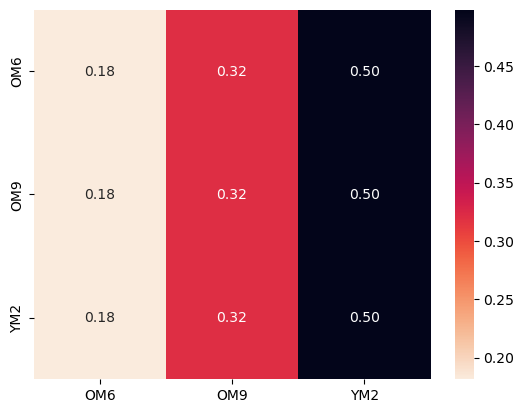

In [32]:
# how do ATAC cell types map to RNA cell types?                                                                                                              
import pandas as pd                                                                                                                                                                     
A = adata_atac[atac_idx].obs["sample"].astype(str).values
R = adata_rna.obs["sample"].astype(str).values                                                                                                                                       
M = pd.DataFrame(T_row, index=A).groupby(level=0).sum()      # (n_atac_ct, n_rna_cells)                                                                                                 
M = M.T.groupby(R).sum().T                                   # (n_atac_ct, n_rna_ct)                                                                                                    
M = M.div(M.sum(1), axis=0)                                                                                                                                                             
sns.heatmap(M, annot=True, fmt=".2f", cmap="rocket_r")

## Multi-ome data

In [ ]:
import muon as mu
# Import a module with ATAC-seq-related functions
from muon import atac as ac

In [ ]:
adata_atac

In [ ]:
# %% TF-IDF normalisation
# muon's tfidf writes the normalised matrix back into .X
ac.pp.tfidf(adata_atac, scale_factor=1e4)

In [ ]:
#add it to layer 
adata_atac.layers["tfidf"] = adata_atac.X.copy()

In [ ]:
# ---- (cell 20 replacement) build MuData from raw soft peaks -----------
import mudata as mu, anndata as ad

peaks    = adata_atac.var_names.to_list()
peak_var = adata_atac.var[["chrom","start","end"]].copy() \
           if {"chrom","start","end"}.issubset(adata_atac.var.columns) else None
if peak_var is None:
    parsed = [p.replace(":", "-").split("-") for p in peaks]
    peak_var = pd.DataFrame(parsed, columns=["chrom","start","end"], index=peaks) \
                 .astype({"start": int, "end": int})

rna  = ad.AnnData(
    X=adata_rna.X if sp.issparse(adata_rna.X) else sp.csr_matrix(adata_rna.X),
    obs=adata_rna.obs.copy(), var=adata_rna.var.copy(),
    obsm={"X_pca": adata_rna.obsm["X_pca"]},
)
atac = ad.AnnData(
    X=sp.csr_matrix(X_peaks_rna),
    obs=adata_rna.obs.copy(), var=peak_var,
)
atac.var_names = peaks
mome = mu.MuData({"rna": rna, "atac": atac})

# ---- (cell 21 replacement) TF-IDF in-place on mome ATAC ---------------
def tfidf(M, scale=1e4):
    M = M.tocsr() if sp.issparse(M) else sp.csr_matrix(M)
    rs  = np.asarray(M.sum(1)).ravel() + 1e-12
    cs  = np.asarray(M.sum(0)).ravel() + 1e-12
    idf = np.log1p(M.shape[0] / cs)
    Mn  = sp.diags(scale / rs) @ M @ sp.diags(idf)
    return Mn.log1p()

mome["atac"].layers["tfidf"] = tfidf(mome["atac"].X)
print(mome)

#### Subset the rna to MaxToki vocab

In [ ]:
mome["rna"].var_names

In [ ]:
import pandas as pd, pyranges as pr, numpy as np

# 1. symbol → ENSG from the same GTF you used for TSS lookup
gtf = pr.read_gtf(f"{human_genome_path}/gencode.v46.annotation.gtf").df
gtf = gtf[gtf.Feature == "gene"][["gene_name", "gene_id"]].drop_duplicates("gene_name")
gtf["gene_id_clean"] = gtf["gene_id"].str.split(".").str[0]    # strip ENSG version
sym2ensg = dict(zip(gtf["gene_name"].astype(str), gtf["gene_id_clean"]))
print(f"GTF mappings: {len(sym2ensg)} symbol→ENSG")

# 2. attach ENSG to mome["rna"].var
syms = mome["rna"].var_names.astype(str)
mome["rna"].var["ensg"] = [sym2ensg.get(s, None) for s in syms]

n_total   = mome["rna"].n_vars
n_mapped  = mome["rna"].var["ensg"].notna().sum()
print(f"{n_mapped}/{n_total} symbols mapped to ENSG  ({n_mapped/n_total:.1%})")

In [ ]:
import json, numpy as np, pandas as pd

# 1. load MaxToki vocab
with open("/projects/bhdw/asachan/methods/maxtoki-perturb/src/maxtoki_mlx/resources/token_dictionary.json") as f:
    vocab = json.load(f)

# strip special tokens to leave only ENSG entries
ensg_to_token = {k: v for k, v in vocab.items() if k.startswith("ENSG")}
print(f"vocab tokens: {len(vocab)} total, {len(ensg_to_token)} ENSG-keyed")

# 2. attach token index to mome["rna"].var
mome["rna"].var["maxtoki_token"] = (
    mome["rna"].var["ensg"].map(ensg_to_token).astype("Int64")  # nullable int
)

n_in_vocab = mome["rna"].var["maxtoki_token"].notna().sum()
print(f"vars with MaxToki token: {n_in_vocab} / {mome['rna'].n_vars} "
      f"({n_in_vocab / mome['rna'].n_vars:.1%})")

In [ ]:
import numpy as np

mask = mome["rna"].var["maxtoki_token"].notna()
print(f"keeping {mask.sum()} / {mome['rna'].n_vars} genes")

# rebuild MuData with subsetted RNA modality, ATAC unchanged
import mudata as mu
rna_sub = mome["rna"][:, mask.values].copy()
rna_sub.var["maxtoki_token"] = rna_sub.var["maxtoki_token"].astype(int)
rna_sub = rna_sub[:, np.argsort(rna_sub.var["maxtoki_token"].values)].copy()  # sort by token id


In [ ]:
# After your subsetting block, before saving
original_rna = mome["rna"]   # whatever the pre-mask version is

# Match by gene id (since order may differ)
gene_to_idx = {g: i for i, g in enumerate(original_rna.var["ensembl_id"].astype(str))}
src_idx = [gene_to_idx[g] for g in rna_sub.var["ensembl_id"].astype(str)]

# Port counts (and any other layer you need)
for layer_name in ("counts",):    # add "lognorm", "spliced", etc. if needed
    if layer_name in original_rna.layers:
        rna_sub.layers[layer_name] = original_rna.layers[layer_name][:, src_idx].copy()
        print(f"[port] {layer_name}: {rna_sub.layers[layer_name].shape}")

mome = mu.MuData({"rna": rna_sub, "atac": mome["atac"]})
print(mome)

In [ ]:
#overwrite mome file 
mome.write_h5mu(f"{out_tmp}/mome_atac_rna_skm.h5mu")

In [ ]:
rna_sub.var["ensembl_id"] = rna_sub.var['ensg']        # if ENSGs are the index

In [ ]:
# write the rna view of this mudata file 
rna_sub.write_h5ad(f"{out_tmp}/rna_view_muon.h5ad")

In [ ]:
rna_maxtoki_input = sc.read_h5ad(f"{out_tmp}/rna_view_muon.h5ad")

In [ ]:
rna_maxtoki_input.var["ensembl_id"]

# Peak to gene (TSS +- 250kb for long-range CRE-peak capture & TF-Motif scan in age-specific open chromatin)

#### TSS finder

In [ ]:
import numpy as np, pandas as pd, scipy.sparse as sp, pyranges as pr
from tqdm.auto import tqdm

# TSS lookup
gtf = pr.read_gtf(f"{human_genome_path}/gencode.v46.annotation.gtf").df
gtf = gtf[gtf.Feature == "gene"][["gene_id","Chromosome","Start","End","Strand"]]
gtf["TSS"]     = np.where(gtf.Strand == "+", gtf.Start, gtf.End)
gtf["gene_id"] = gtf["gene_id"].str.split(".").str[0]
tss = gtf.drop_duplicates("gene_id").set_index("gene_id")[["Chromosome","TSS"]]

atac, rna = mome["atac"], mome["rna"]
genes_e   = rna.var["ensg"].astype(str).values
peak_mid  = ((atac.var["start"].astype(int) + atac.var["end"].astype(int)) // 2).values
peak_chr  = atac.var["chrom"].astype(str).values
peak_by_chr = {ch: (np.where(peak_chr==ch)[0], peak_mid[peak_chr==ch])
               for ch in np.unique(peak_chr)}

WIN, SCALE = 250_000, 50_000 # distance -decay based likelihood
present = np.isin(genes_e, tss.index.values)
print(f"{present.sum():,}/{len(genes_e):,} genes have TSS")

cand_p, cand_g, cand_w = [], [], []
for gi in tqdm(np.where(present)[0], desc="P2G distance-decay"):
    e = genes_e[gi]
    chrom, t = tss.at[e, "Chromosome"], int(tss.at[e, "TSS"])
    if chrom not in peak_by_chr: continue
    p_idx, p_mid = peak_by_chr[chrom]
    d = np.abs(p_mid - t)
    m = d <= WIN
    if m.any():
        cand_p.append(p_idx[m])
        cand_g.append(np.full(m.sum(), gi, dtype=np.int64))
        cand_w.append(np.exp(-d[m] / SCALE).astype(np.float32))

cand_p = np.concatenate(cand_p); cand_g = np.concatenate(cand_g); cand_w = np.concatenate(cand_w)
P2G = sp.csr_matrix((cand_w, (cand_p, cand_g)), shape=(atac.n_vars, rna.n_vars))
print("P2G:", P2G.shape, "nnz:", P2G.nnz)
sp.save_npz(f"{out_tmp}/P2G.npz", P2G)

In [ ]:
import numpy as np, scipy.sparse as sp, pandas as pd
import matplotlib.pyplot as plt

X_open = mome["atac"].X.toarray() if sp.issparse(mome["atac"].X) else mome["atac"].X
# (n_cells, n_peaks) @ (n_peaks, n_genes) = (n_cells, n_genes) regulatory mass
reg_mass = X_open @ P2G                                                      # dense

ages = mome["rna"].obs["age_categorical"].astype(str).values
mask80 = ages == "80"; mask34 = ages == "34"

mean80 = reg_mass[mask80].mean(0); mean34 = reg_mass[mask34].mean(0)
log2fc = np.log2((mean80 + 1e-6) / (mean34 + 1e-6))

# rough significance via Welch t-test
from scipy.stats import ttest_ind
_, pvals = ttest_ind(reg_mass[mask80], reg_mass[mask34], axis=0, equal_var=False)
nlogp = -np.log10(np.clip(pvals, 1e-50, 1))


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

hits = (np.abs(log2fc) > 0.5) & (pvals < 1e-5)

N = 5
nlogp_safe = np.where(hits, nlogp, -np.inf)
top_up   = np.argsort(np.where(log2fc > 0, nlogp_safe, -np.inf))[::-1][:N]
top_down = np.argsort(np.where(log2fc < 0, nlogp_safe, -np.inf))[::-1][:N]

top_df = pd.DataFrame({
    "gene":      np.concatenate([mome["rna"].var_names.values[top_up],
                                 mome["rna"].var_names.values[top_down]]),
    "log2fc":    np.concatenate([log2fc[top_up],   log2fc[top_down]]),
    "-log10(p)": np.concatenate([nlogp[top_up],    nlogp[top_down]]),
    "side":      ["80↑"] * N + ["34↑"] * N,
})
print(top_df)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(log2fc, nlogp, s=4, alpha=0.4, c="grey")
ax.scatter(log2fc[hits], nlogp[hits], s=8, c="crimson")
ax.axhline(-np.log10(1e-5), ls="--", c="k", lw=0.6)
ax.axvline( 0.5, ls="--", c="k", lw=0.6); ax.axvline(-0.5, ls="--", c="k", lw=0.6)
ax.set_xlabel("log2( mass[80] / mass[34] )")
ax.set_ylabel("-log10(p)")
ax.set_title("Differential per-gene peak mass transported through GW-OT: 80yo vs 34yo")

# legend-style text boxes inside the plot
def gene_box(genes, color, header, loc):
    text = header + "\n" + "\n".join(genes)
    box  = AnchoredText(
        text, loc=loc, prop=dict(color=color, fontsize=10, fontweight="bold"),
        frameon=True, borderpad=0.5, pad=0.4,
    )
    box.patch.set_boxstyle("round,pad=0.3")
    box.patch.set_edgecolor(color)
    box.patch.set_facecolor("white")
    box.patch.set_alpha(0.85)
    return box

ax.add_artist(gene_box(
    [mome["rna"].var_names[gi] for gi in top_down],
    color="darkred",  header="More open TSS sites in young (34 y/o)", loc="upper left"
))
ax.add_artist(gene_box(
    [mome["rna"].var_names[gi] for gi in top_up],
    color="darkblue", header="More open TSS sites in old (80 y/o)",  loc="upper right"
))

plt.tight_layout()
fig.savefig(f"{out_tmp}/volcano_p2g_age.svg", format="svg", bbox_inches="tight")
plt.show()

# MaxToki finetune prep — peak-aware attention **sparsity mask**

The 217M MaxToki backbone (11 layers, fully-connected gene–gene SDPA) stays
**frozen and unchanged** — finetuning's only job is to make attention *sparser
and biology-aware*. Inside each cell we want attention to concentrate on the
genes whose chromatin is open in **that cell**: a young cell attends to one
gene set, an old cell to another.

We already have, per RNA cell `c` and gene `g`, the peak mass

$$\text{reg\_mass}[c, g] \;=\; \sum_{p}\; X_\text{peaks\_rna}[c, p]\;P2G[p, g]$$

i.e. how much TSS-distance-decayed peak mass sits over gene *g*'s regulatory
neighbourhood in cell *c* (cell 46 already computes this for the volcano).

For finetuning we convert `reg_mass` into a per-cell **binary key-mask** over
RVE token positions:

```
mask[c, j] = True   if  gene_at_pos_j is "open" in cell c
                       (reg_mass[c, gene_pos[j]]  >=  threshold[sample(c)])
                    OR  position j is a special token (<bos>/<eos>)
mask[c, j] = False  otherwise   ->   add -inf at this *key* column inside SDPA
```

This is broadcast across query rows so every gene token still **queries**, but
only **attends to** keys gated open by chromatin. Frozen base attention
weights, sparser attention pattern at finetune time.

**Threshold rule (default).** For each donor sample *s*:

```
threshold[s] = multiplier * median( reg_mass[cells_in_s, :]  > 0 )
```

i.e. the median of nonzero `reg_mass` entries within the sample, scaled by an
optional `multiplier` (default 1.0). This naturally adapts to per-sample
sequencing depth and chromatin landscape — typically keeping ~half the
nonzero gene tokens per cell as attendable keys. A `min_keep` floor (default
32) catches degenerate cells with too few open genes, falling back to top-K
by mass.

In [ ]:
# torch_pipeline tokenizer (no MLX dep) — same RVE algorithm as maxtoki_mlx.
# It picks up token_dictionary.json + gene_median.json from
#   <repo>/src/maxtoki_mlx/resources/  (same files cell 35 already references).
# To use the temporal-aware dict (with <boq>/<eoq>/numeric tokens) for
# TimeBetweenCells finetune later, set MAXTOKI_TOKEN_DICT in the env.
import sys
TORCH_PIPE = "/projects/bhdw/asachan/methods/maxtoki-perturb/scripts/torch_pipeline"
if TORCH_PIPE not in sys.path:
    sys.path.insert(0, TORCH_PIPE)

from tokenizer import CellTokenizer, MODEL_INPUT_SIZE  # type: ignore

tok = CellTokenizer()
print(f"vocab={len(tok.token_dict)}  genes_with_median={tok.num_genes}  "
      f"bos={tok.bos_id}  eos={tok.eos_id}  model_input_size={MODEL_INPUT_SIZE}  "
      f"has_temporal_tokens={tok.has_temporal_tokens}")

In [ ]:
# rna_sub was vocab-subset in cell 36, but the tokenizer additionally needs a
# gene_median entry per ENSG. Verify alignment.
ensg = rna_sub.var["ensg"].astype(str).values
in_tok = np.array([tok.has_gene(e) for e in ensg])
print(f"rna_sub genes accepted by MaxToki tokenizer: {in_tok.sum():,}/{len(in_tok):,} "
      f"({in_tok.mean():.1%})")
if not in_tok.all():
    drop = ensg[~in_tok][:5]
    print(f"  example dropped (no median): {list(drop)}")

In [ ]:
# RVE tokenize each cell while remembering the gene_idx (in rna_sub.var) at every
# token position. The rank logic mirrors CellTokenizer.tokenize_expression.
import numpy as np, scipy.sparse as sp
from tqdm.auto import tqdm

def rve_tokenize_with_positions(adata, tok, max_len=MODEL_INPUT_SIZE,
                                count_layer="counts", target_sum=1e4):
    """Returns parallel python lists, one entry per cell:
        input_ids[c]      : list[int]  -- [<bos>, gene_tok_1, ..., <eos>]
        gene_positions[c] : list[int]  -- gene_idx in adata.var (or -1 for specials)
        n_counts[c]       : float
    The gene_idx-per-position arrays are what the dataloader uses at train time
    to slice P2G when building the bias for each cell."""
    X = adata.layers[count_layer] if count_layer in adata.layers else adata.X
    X = sp.csr_matrix(X) if not sp.issparse(X) else X.tocsr()
    ensg = adata.var["ensg"].astype(str).values

    tok_id = np.full(adata.n_vars, -1, dtype=np.int64)
    median = np.full(adata.n_vars, np.nan, dtype=np.float64)
    for j, e in enumerate(ensg):
        if tok.has_gene(e):
            tok_id[j] = tok.gene_token(e)
            median[j] = tok.gene_median[e]
    keep = tok_id >= 0
    bos, eos = tok.bos_id, tok.eos_id

    ids_out, pos_out, n_out = [], [], []
    for i in tqdm(range(adata.n_obs), desc="RVE tokenize"):
        row = X[i].toarray().ravel().astype(np.float64)
        nc  = float(row.sum())
        if nc <= 0:
            ids_out.append([bos, eos]); pos_out.append([-1, -1]); n_out.append(0.0); continue
        scores = (row / nc) * target_sum
        m = keep & (row > 0)
        idx = np.where(m)[0]
        scores = scores[idx] / median[idx]
        order  = np.argsort(-scores, kind="stable")
        ranked = idx[order]
        if ranked.size > max_len - 2:
            ranked = ranked[:max_len-2]
        ids_out.append(np.concatenate([[bos], tok_id[ranked], [eos]]).astype(np.int64).tolist())
        pos_out.append(np.concatenate([[-1],  ranked,         [-1]]).astype(np.int64).tolist())
        n_out.append(nc)
    return ids_out, pos_out, n_out

input_ids, gene_positions, n_counts = rve_tokenize_with_positions(rna_sub, tok)
seq_lens = np.array([len(x) for x in input_ids])
print(f"seq_len  min/median/p95/max = "
      f"{seq_lens.min()}/{int(np.median(seq_lens))}/{int(np.percentile(seq_lens,95))}/{seq_lens.max()}")
print(f"cells with truncated RVE (=={MODEL_INPUT_SIZE}): "
      f"{(seq_lens == MODEL_INPUT_SIZE).sum()}/{len(seq_lens)}")

In [ ]:
# Reference key-mask builder — this is the function the maxtoki-perturb
# finetune dataloader imports verbatim.
import numpy as np, scipy.sparse as sp

# reg_mass = (n_cells, n_genes_rna_sub).  Cell 46 already computed this for
# the volcano; recompute defensively in case this section is run standalone.
if "reg_mass" not in dir():
    X_open   = mome["atac"].X.toarray() if sp.issparse(mome["atac"].X) else mome["atac"].X
    reg_mass = (X_open @ P2G).astype(np.float32)
reg_mass_csr = sp.csr_matrix(reg_mass)                 # streaming-friendly

def build_attn_keep_mask(cell_i, gene_pos, reg_mass_csr, threshold,
                         min_keep=32):
    """Per-cell binary key-mask over RVE token positions.

    Returns a bool array of length len(gene_pos):
        True  -> token is attendable as a key (special token, OR gene with
                 reg_mass >= threshold, OR fallback top-`min_keep` by mass)
        False -> mask out (add -inf at this key column inside SDPA).

    Specials (<bos>/<eos>, gene_pos == -1) are always kept."""
    gp    = np.asarray(gene_pos, dtype=np.int64)
    keep  = np.ones(len(gp), dtype=bool)
    valid = gp >= 0
    if not valid.any():
        return keep                                    # only specials
    mass_row    = np.asarray(reg_mass_csr[cell_i].todense()).ravel()
    mass_at_pos = mass_row[gp[valid]]
    keep_pos    = mass_at_pos >= threshold
    # min_keep floor: ensure at least min_keep gene-tokens stay attendable
    if keep_pos.sum() < min_keep and len(mass_at_pos) >= min_keep:
        order = np.argsort(-mass_at_pos)               # high mass first
        floor = np.zeros_like(keep_pos)
        floor[order[:min_keep]] = True
        keep_pos = keep_pos | floor
    keep[valid] = keep_pos
    return keep

def keep_mask_to_attn_bias(keep, dtype=np.float32):
    """Boolean keep-mask -> additive (seq_len,) bias for SDPA / flash-attn:
    0 at attendable keys, -inf at masked keys.  Broadcast across queries."""
    bias = np.zeros(len(keep), dtype=dtype)
    bias[~keep] = -np.inf
    return bias

# Per-sample thresholds: median of nonzero reg_mass entries within each donor.
THRESH_MULTIPLIER = 1.0          # tune ~ in [0.5, 2.0] to control sparsity
samples_arr = rna_sub.obs["sample"].astype(str).values
thresholds  = {}
for s in sorted(np.unique(samples_arr)):
    sub = reg_mass[samples_arr == s]
    nz  = sub[sub > 0]
    thresholds[s] = float(THRESH_MULTIPLIER * np.median(nz)) if nz.size else 0.0
print("per-sample reg_mass thresholds (median of nonzero entries x "
      f"{THRESH_MULTIPLIER}):")
for s, t in thresholds.items():
    print(f"  {s:>8s}: {t:.4f}")

In [ ]:
# Demo 1: attendable fraction per cell (how sparse did we get?)
keep_frac = np.zeros(rna_sub.n_obs, dtype=np.float32)
for c in range(rna_sub.n_obs):
    keep = build_attn_keep_mask(c, gene_positions[c], reg_mass_csr,
                                thresholds[samples_arr[c]])
    keep_frac[c] = keep.mean()
print(f"attendable-fraction per cell  "
      f"p5={np.percentile(keep_frac,5):.2f}  "
      f"median={np.median(keep_frac):.2f}  "
      f"p95={np.percentile(keep_frac,95):.2f}")

# Demo 2: biology check — does the kept gene set differ between young and old?
# Aggregate per-gene "kept fraction" within each age bucket.
ages = rna_sub.obs["age_categorical"].astype(str).values
unique_ages = sorted(np.unique(ages))
if len(unique_ages) >= 2:
    a_y, a_o = unique_ages[0], unique_ages[-1]
    kept_y = np.zeros(rna_sub.n_vars, dtype=np.int64)
    kept_o = np.zeros(rna_sub.n_vars, dtype=np.int64)
    for c in range(rna_sub.n_obs):
        keep = build_attn_keep_mask(c, gene_positions[c], reg_mass_csr,
                                    thresholds[samples_arr[c]])
        gp = np.asarray(gene_positions[c], dtype=np.int64)
        valid = gp >= 0
        if ages[c] == a_y:
            kept_y[gp[valid][keep[valid]]] += 1
        elif ages[c] == a_o:
            kept_o[gp[valid][keep[valid]]] += 1
    n_y, n_o = max(1, (ages == a_y).sum()), max(1, (ages == a_o).sum())
    delta = kept_o.astype(np.float64) / n_o - kept_y.astype(np.float64) / n_y
    print(f"\ngenes kept much more often in {a_o} than {a_y}:")
    for g in np.argsort(-delta)[:10]:
        print(f"  {rna_sub.var_names.values[g]:18s}  "
              f"keep_frac[{a_o}]={kept_o[g]/n_o:.2f}  "
              f"keep_frac[{a_y}]={kept_y[g]/n_y:.2f}  delta={delta[g]:+.2f}")
    print(f"\ngenes kept much more often in {a_y} than {a_o}:")
    for g in np.argsort( delta)[:10]:
        print(f"  {rna_sub.var_names.values[g]:18s}  "
              f"keep_frac[{a_y}]={kept_y[g]/n_y:.2f}  "
              f"keep_frac[{a_o}]={kept_o[g]/n_o:.2f}  delta={delta[g]:+.2f}")

In [ ]:
# Write the finetune bundle.
import json, scipy.sparse as sp
from pathlib import Path

bundle = Path(out_tmp) / "maxtoki_finetune_skm"
bundle.mkdir(parents=True, exist_ok=True)

# 1. sparse arrays for transparency / on-the-fly mask reconstruction
sp.save_npz(bundle / "reg_mass.npz",    reg_mass_csr)
sp.save_npz(bundle / "P2G.npz",         P2G.tocsr())
sp.save_npz(bundle / "X_peaks_rna.npz", sp.csr_matrix(X_peaks_rna))

# 2. cells.parquet — one row per cell, with a precomputed keep_mask so the
#    dataloader doesn't have to touch reg_mass at __getitem__ time.
keep_masks = []
for c in range(rna_sub.n_obs):
    keep = build_attn_keep_mask(c, gene_positions[c], reg_mass_csr,
                                thresholds[samples_arr[c]])
    keep_masks.append(keep.astype(bool).tolist())

try:
    import pyarrow as pa, pyarrow.parquet as pq

    cells_tbl = pa.table({
        "cell_id":         pa.array([str(x) for x in rna_sub.obs_names.values]),
        "input_ids":       pa.array(input_ids,      type=pa.list_(pa.int64())),
        "gene_positions":  pa.array(gene_positions, type=pa.list_(pa.int64())),
        "keep_mask":       pa.array(keep_masks,     type=pa.list_(pa.bool_())),
        "n_counts":        pa.array(n_counts,       type=pa.float64()),
        "age_categorical": pa.array([str(x) for x in rna_sub.obs["age_categorical"].values]),
        "sample":          pa.array([str(x) for x in rna_sub.obs["sample"].values]),
    })
    pq.write_table(cells_tbl, bundle / "cells.parquet")

    gene_tbl = pa.table({
        "gene_idx":      pa.array(np.arange(rna_sub.n_vars, dtype=np.int64)),
        "ensg":          pa.array(rna_sub.var["ensg"].astype(str).values),
        "symbol":        pa.array(rna_sub.var_names.astype(str).values),
        "maxtoki_token": pa.array(rna_sub.var["maxtoki_token"].astype(np.int64).values),
    })
    pq.write_table(gene_tbl, bundle / "genes.parquet")

    av = mome["atac"].var
    peak_tbl = pa.table({
        "peak_idx": pa.array(np.arange(av.shape[0], dtype=np.int64)),
        "chrom":    pa.array(av["chrom"].astype(str).values),
        "start":    pa.array(av["start"].astype(np.int64).values),
        "end":      pa.array(av["end"].astype(np.int64).values),
    })
    pq.write_table(peak_tbl, bundle / "peaks.parquet")
except ImportError:
    import pickle
    pickle.dump({"input_ids": input_ids, "gene_positions": gene_positions,
                 "keep_mask": keep_masks, "n_counts": n_counts,
                 "cell_id":  rna_sub.obs_names.astype(str).tolist(),
                 "age":      rna_sub.obs["age_categorical"].astype(str).tolist(),
                 "sample":   rna_sub.obs["sample"].astype(str).tolist()},
                open(bundle / "cells.pkl", "wb"))

# 3. manifest — recipe + paths the finetune script needs
TOK_DICT_PATH = "/projects/bhdw/asachan/methods/maxtoki-perturb/src/maxtoki_mlx/resources/token_dictionary.json"
GENE_MED_PATH = "/projects/bhdw/asachan/methods/maxtoki-perturb/src/maxtoki_mlx/resources/gene_median.json"

manifest = {
    "n_cells":          int(rna_sub.n_obs),
    "n_genes":          int(rna_sub.n_vars),
    "n_peaks":          int(mome["atac"].n_vars),
    "model_input_size": int(MODEL_INPUT_SIZE),
    "tokenizer": {
        "token_dict":  TOK_DICT_PATH,
        "gene_median": GENE_MED_PATH,
        "vocab_size":  int(len(tok.token_dict)),
        "bos_id":      int(tok.bos_id),
        "eos_id":      int(tok.eos_id),
    },
    "ot": {
        "stratification": "sample (per-donor GW couplings, sample-block-diagonal coupling enforced)",
        "T_dir":          str(Path(out_tmp) / "T_npy_sample_matched"),
    },
    "p2g": {
        "win_bp":   250_000,
        "scale_bp": 50_000,
        "decay":    "exp(-d/scale)",
        "shape":    list(P2G.shape),
        "nnz":      int(P2G.nnz),
    },
    "attn_sparsity": {
        "intent":          "freeze 217M backbone gene-gene SDPA; finetune ADDS a peak-aware key-mask so each cell only attends to chromatin-open genes",
        "rule":            "additive bias  -inf at key positions where gene at that position has reg_mass < sample_threshold; 0 elsewhere; specials always attendable",
        "threshold_recipe":"per-sample median of nonzero reg_mass entries (cells_in_s x genes_rna_sub)",
        "multiplier":      float(THRESH_MULTIPLIER),
        "min_keep":        32,
        "thresholds":      {str(s): float(t) for s, t in thresholds.items()},
        "keep_frac_p5":    float(np.percentile(keep_frac, 5)),
        "keep_frac_p50":   float(np.median(keep_frac)),
        "keep_frac_p95":   float(np.percentile(keep_frac, 95)),
    },
    "files": {
        "reg_mass":    "reg_mass.npz     (csr  n_cells x n_genes)  -- per-cell per-gene peak mass; source of the mask",
        "P2G":         "P2G.npz          (csr  n_peaks x n_genes)",
        "X_peaks":     "X_peaks_rna.npz  (csr  n_cells x n_peaks)",
        "cells":       "cells.parquet    (one row per cell, with input_ids, gene_positions, keep_mask)",
        "genes":       "genes.parquet",
        "peaks":       "peaks.parquet",
    },
}
(bundle / "manifest.json").write_text(json.dumps(manifest, indent=2))
print("bundle:", bundle)
for p in sorted(bundle.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size/1e6:.1f} MB)")

### Hand-off to maxtoki-perturb

The finetune dataloader consumes the bundle with a single per-cell **boolean key-mask** that gets folded into SDPA as an additive bias:

```python
import pyarrow.parquet as pq, json, numpy as np, torch

bundle   = "/projects/bhdw/asachan/tmp/maxtoki_finetune_skm"
manifest = json.load(open(f"{bundle}/manifest.json"))
cells    = pq.read_table(f"{bundle}/cells.parquet").to_pandas()

# Per-row at __getitem__ time:
def make_row(i):
    r    = cells.iloc[i]
    ids  = np.asarray(r.input_ids,  dtype=np.int64)         # [<bos>, ..., <eos>]
    keep = np.asarray(r.keep_mask,  dtype=bool)             # length L
    bias = np.zeros(len(keep), dtype=np.float32)
    bias[~keep] = float("-inf")                             # mask -inf at low-mass keys
    return ids, bias                                        # bias broadcast across queries

# Per-batch:  pad ids and bias to max-len; the padding columns also get -inf.
# Inside the model, on every layer's SDPA call:
#   logits = (Q @ K.T) / sqrt(d)
#   logits = logits + bias[None, None, None, :]            # (B,H,Lq,Lk) + (1,1,1,Lk)
#   attn   = softmax(logits, dim=-1)
# i.e. each query token still queries, but its attention is sparsified to the
# chromatin-open key set defined by reg_mass + per-sample threshold.  Backbone
# weights are frozen; only the LM head / adapter / LoRA on top is trained.
```

### Knobs to sweep

* `THRESH_MULTIPLIER` (cell 52, default 1.0) — raise to 2× for stricter sparsity (≈25% kept), drop to 0.5× for permissive (≈75% kept).
* `min_keep` (cell 52, default 32) — floor on attendable gene tokens per cell, prevents degenerate cells with near-empty key sets.
* `THRESHOLD_RECIPE` — current default is per-sample median of nonzero `reg_mass` entries; alternatives worth trying:
    - per-cell quantile (q=0.5 of nonzero entries in each cell)
    - global top-K-per-cell (e.g. K=512)
  Both can be slotted into `build_attn_keep_mask` without touching the finetune side.